In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

In [2]:
IMAGE_SIZE=256
BATCH_SIZE=32
CHANNELS=3
EPOCHS=50

In [4]:
dataset=tf.keras.preprocessing.image_dataset_from_directory(   # here first we wrote is folder name adn image size we can se dimentions in properties of image
    "PlantVillage",
    shuffle=True,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE
)                                                   # 3 classes means 3 floders are there in directory Plant Village

Found 20638 files belonging to 15 classes.


In [5]:
class_names=dataset.class_names
class_names

['Pepper__bell___Bacterial_spot',
 'Pepper__bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato__Target_Spot',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_healthy']

In [6]:
len(dataset)   #here 68 we got bcoz every image is a batch of 32 so 68*32=2176 i.e total images

645

(32, 256, 256, 3)
[13 10  9 12  6  3 11  3  9  6  6  8 14  1  9  7  2  7  1 12  5  9 11 10
  9  9  7 12  0  5 12 14]
(256, 256, 3)


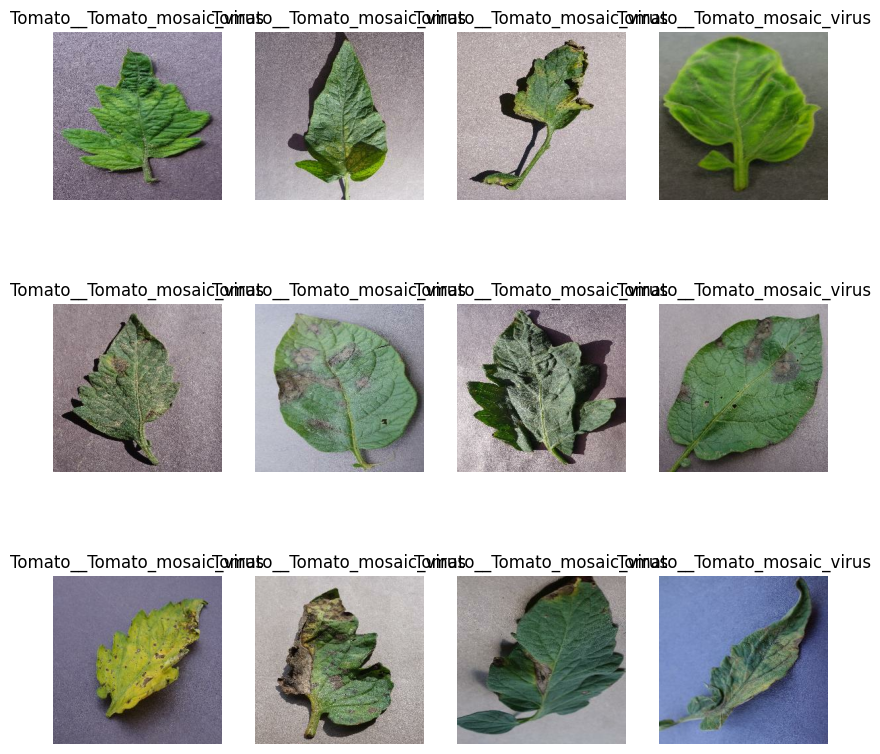

In [7]:
plt.figure(figsize=(10,10))  # to increase the distance between images
for image_batch,label_batch in dataset.take(1):
    for i in range(12):
        ax=plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))  # to display the image and to convert it to int uint8
        plt.axis("off") # it will not show x and y axis for the image
        plt.title(class_names[label_batch[0]])
        
    
    print(image_batch.shape)
    print(label_batch.numpy())
    print(image_batch[0].shape)

In [8]:
len(dataset)

645

In [8]:
 # 80% ==> training
 # 20% ==> 10% validation, 10% test

In [9]:
trian_size=0.8
len(dataset)*trian_size

54.400000000000006

In [10]:
train_ds=dataset.take(54)
len(train_ds)

54

In [11]:
test_ds=dataset.skip(54) # skipping first 54
len(test_ds)

14

In [12]:
val_size=0.1
len(dataset)*val_size

6.800000000000001

In [13]:
val_ds=test_ds.take(6)
len(val_ds)

6

In [14]:
test_ds=test_ds.skip(6)  # skip first 6 in 14 means 8
len(test_ds)

8

In [15]:
def get_dataset_partitions_tf(ds,train_split=0.8,val_split=0.1,test_split=0.1,shuffle=True,shuffle_size=10000):

    ds_size=len(ds)

    if shuffle:
        ds=ds.shuffle(shuffle_size,seed=12) # if we do same seed everytime we get same result or else every time random shuffle and we get different
        
    train_size=int(train_split*ds_size)
    val_size=int(val_split*ds_size)

    train_ds=ds.take(train_size)
    
    val_ds=ds.skip(train_size).take(val_size)
    test_ds=ds.skip(train_size).skip(val_size)

    return train_ds,val_ds,test_ds

In [16]:
train_ds,val_ds,test_ds=get_dataset_partitions_tf(dataset)  # to split the dataset in train,test,valuation

In [17]:
len(train_ds)

54

In [18]:
len(val_ds)

6

In [19]:
len(test_ds)

8

In [20]:
train_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE) # here .cache catches the dataset from memory after the first epoch
val_ds=val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE) # .shuffle() shuffles the dataset with buffer size of 1000
test_ds=test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE) # allows the pipline the fetch batches in background  while the model is training the current data,actually when fetching is going on training is stopeed and vice verse so to save time and to do 2 tasks at same time we use perfetch

In [21]:
from tensorflow.keras.models import Sequential

resize_and_rescale=tf.keras.Sequential([    # we are resizing it bcoz if some image is not of 256X256 so resize it
    layers.Resizing(IMAGE_SIZE,IMAGE_SIZE),
    layers.Rescaling(1.0/255)
])

In [22]:
data_augmentation=tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),  # we change the direction of images bcoz when given in differnt direction out model should be able to identify the image
    layers.RandomRotation(0.2),
])
    

In [23]:
input_shape=(BATCH_SIZE,IMAGE_SIZE,IMAGE_SIZE,CHANNELS)
n_classes=3

model=models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32,(3,3),activation='relu',input_shape=input_shape), # doing the same operation of 1st 2 lines 5 times then flattenign,densing
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(n_classes,activation='softmax'),
])

model.build(input_shape=input_shape)

C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (32, 256, 256, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (32, 256, 256, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (32, 254, 254, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (32, 127, 127, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (32, 125, 125, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (32, 62, 62, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (32, 60, 60, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (32, 30, 30, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (32, 28, 28, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (32, 14, 14, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (32, 12, 12, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (32, 6, 6, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (32, 4, 4, 64)              │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (32, 2, 2, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (32, 256)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (32, 64)                    │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (32, 3)                     │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [123]:
EPOCHS=50

In [125]:
history=model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    validation_data=val_ds
)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 192s 3s/step - accuracy: 0.9922 - loss: 0.0210 - val_accuracy: 0.9531 - val_loss: 0.1530
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 278s 5s/step - accuracy: 0.9916 - loss: 0.0387 - val_accuracy: 0.9844 - val_loss: 0.0423
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 171s 3s/step - accuracy: 0.9944 - loss: 0.0154 - val_accuracy: 0.9792 - val_loss: 0.0929
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 172s 3s/step - accuracy: 0.9990 - loss: 0.0086 - val_accuracy: 0.9688 - val_loss: 0.0953
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 186s 3s/step - accuracy: 0.9979 - loss: 0.0082 - val_accuracy: 0.9896 - val_loss: 0.0466
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 155s 3s/step - accuracy: 0.9959 - loss: 0.0137 - val_accuracy: 0.9479 - val_loss: 0.1831
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 176s 3s/step - accuracy: 0.9693 - loss: 0.0855 - val_accuracy: 0.9479 - val_loss: 0.1281
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 257s 5s/step - accuracy: 0.9966 - loss: 0.0169 - val_accuracy: 0.9896 - v

In [129]:
scores # here if 50 epoches we get 98 accuracy here only 10 epoches so 95 is accuracy

[0.04593396931886673, 0.9765625]

In [127]:
scores=model.evaluate(test_ds) 

8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 806ms/step - accuracy: 0.9659 - loss: 0.0476


In [131]:
history

In [133]:
history.params

{'verbose': 1, 'epochs': 50, 'steps': 54}

In [135]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [137]:
history.history['accuracy']

[0.9918981194496155,
 0.9907407164573669,
 0.9959490895271301,
 0.9982638955116272,
 0.9971064925193787,
 0.9936342835426331,
 0.9716435074806213,
 0.9942129850387573,
 0.9942129850387573,
 0.9895833134651184,
 0.9947916865348816,
 0.9976851940155029,
 0.9849537014961243,
 0.9953703880310059,
 0.9913194179534912,
 0.9878472089767456,
 0.9820601940155029,
 0.9675925970077515,
 0.9901620149612427,
 0.9907407164573669,
 0.9936342835426331,
 0.9971064925193787,
 0.984375,
 0.9918981194496155,
 0.9907407164573669,
 0.9884259104728699,
 0.9947916865348816,
 0.9982638955116272,
 0.9947916865348816,
 0.9918981194496155,
 0.9965277910232544,
 0.9924768805503845,
 0.9918981194496155,
 0.9681712985038757,
 0.9930555820465088,
 0.9982638955116272,
 0.9901620149612427,
 0.9953703880310059,
 0.9976851940155029,
 0.9930555820465088,
 0.9890046119689941,
 0.9959490895271301,
 0.9994212985038757,
 1.0,
 0.9988425970077515,
 0.9947916865348816,
 0.9971064925193787,
 1.0,
 1.0,
 0.9965277910232544]

In [139]:
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']

loss=history.history['loss']
val_loss=history.history['val_loss']

Text(0.5, 1.0, 'Training and Validation Accuracy')

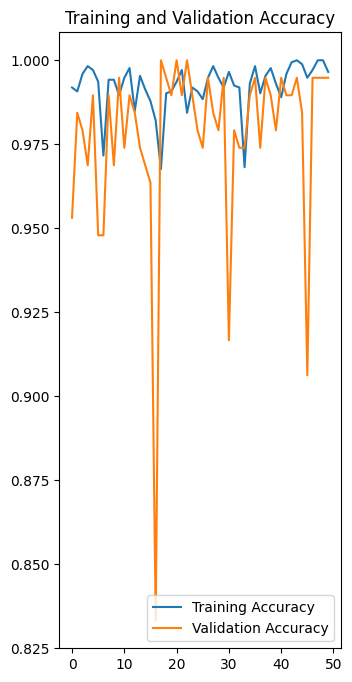

In [141]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,2)
plt.plot(range(EPOCHS),acc,label='Training Accuracy')
plt.plot(range(EPOCHS),val_acc,label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')



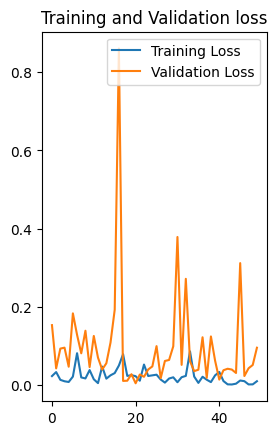

In [143]:
plt.subplot(1,2,2)
plt.plot(range(EPOCHS),loss,label='Training Loss')
plt.plot(range(EPOCHS),val_loss,label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation loss')
plt.show()

In [145]:
import numpy as np
np.argmax([0.00320611, 0.8133325, 0.18346138]) # means at 1st posiotn has max probabilty 

1

first image to predict
actual label: Potato___Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 788ms/step
Predicted label: Potato___Late_blight


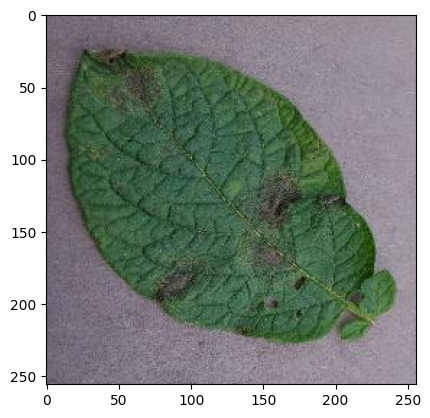

In [147]:

for images_batch,labels_batch in test_ds.take(1):
    first_image=images_batch[0].numpy().astype('uint8')
    first_label=labels_batch[0].numpy()

    print('first image to predict')
    plt.imshow(first_image)
    print("actual label:",class_names[first_label]) 

    batch_prediction=model.predict(images_batch)
    print("Predicted label:",class_names[np.argmax(batch_prediction[0])])  # here batch_prediction we get probabilty of all 3 classes and then we select max probability with np.argmax and class name to get the name of teh max probabity class
    # as we can see below out actaul label and predicted label are same out model is working fine

In [148]:
def predict(model,img):
    img_array=tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array=tf.expand_dims(img_array,0) # create a batch

    prediction=model.predict(img_array)

    predicted_class=class_names[np.argmax(prediction[0])]
    confidence=round(100*(np.max(prediction[0])),2)  # here we are multiplying prediction value with 100 to get % of confidence 
    return predicted_class,confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


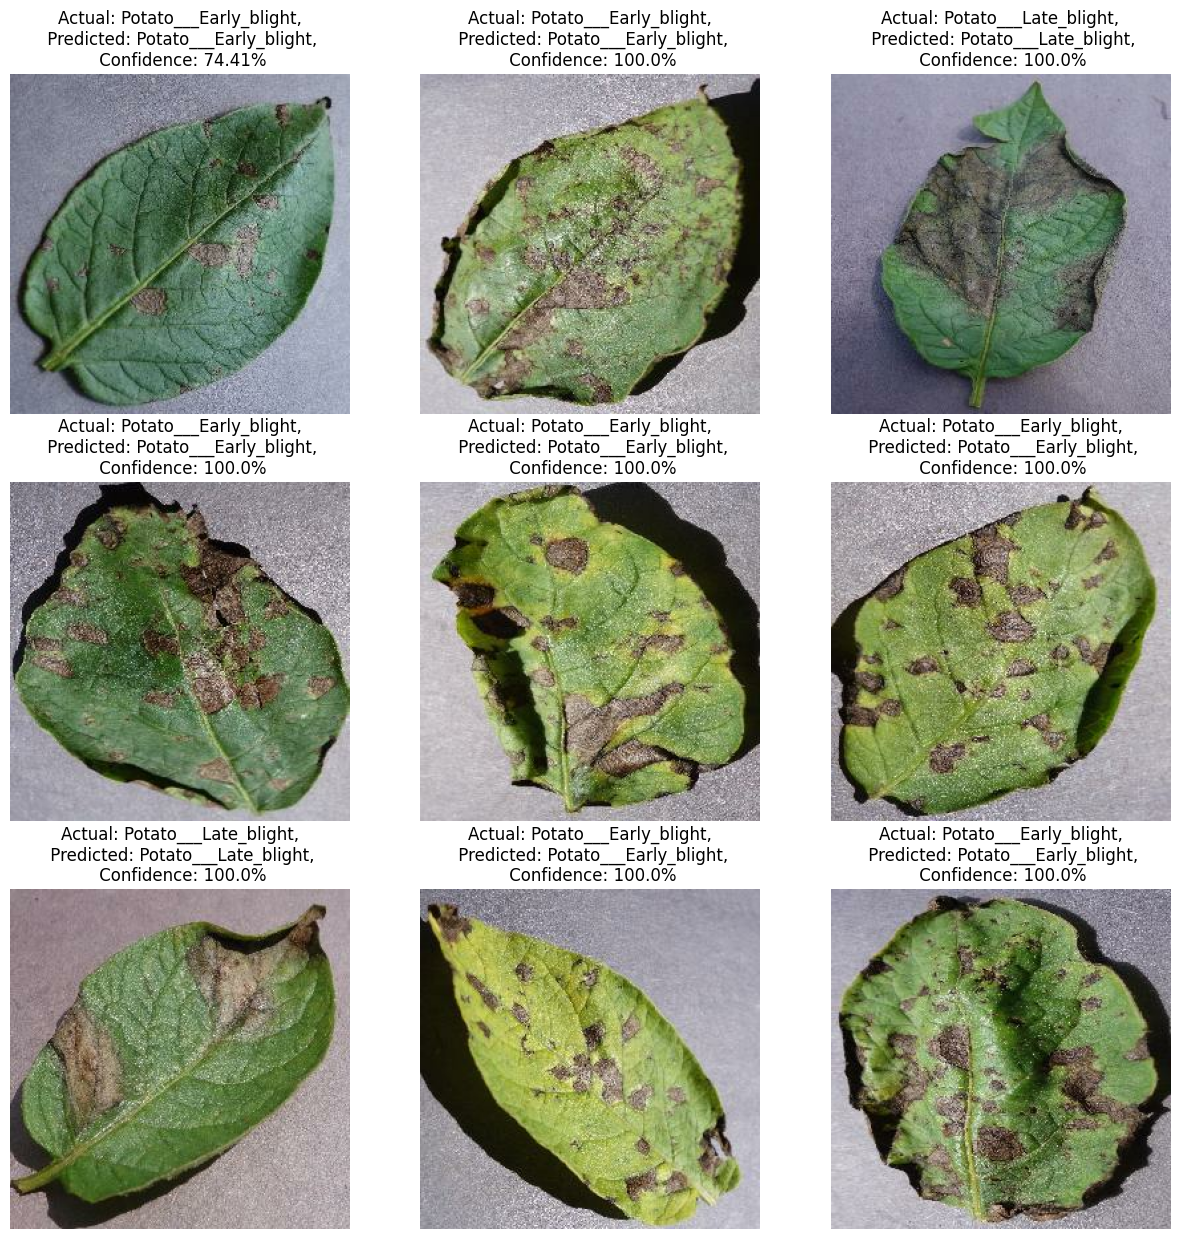

In [149]:
plt.figure(figsize=(15,15))  # to get images bigger and increase distance bw images
for images,labels in test_ds.take(1):
    for i in range(9):
        ax=plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class,confidence=predict(model,images[i].numpy())
        actual_class=class_names[labels[i]]
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class},\n Confidence: {confidence}%")
        
        plt.axis("off")
        